# PyCalPhad

There are many open-source Python libraries open to public online. In this notebook file, we shall explore a Python library of CalPhad (Calculated Phase Diagram, which is a standard method to make phase diagram from thermodynamic free energies).

- Search PyCalPhad online.
- Explore the example problems
- Bindary system
- Ternary system
  

In [ ]:
!pip install -U pycalphad

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from pycalphad import Database, binplot
import pycalphad.variables as v

# Load database and choose the phases that will be considered
db_alzn = Database('alzn_mey.tdb')
my_phases_alzn = ['LIQUID', 'FCC_A1', 'HCP_A3']

# Create a matplotlib Figure object and get the active Axes
fig = plt.figure(figsize=(9,6))
axes = fig.gca()

# Compute the phase diagram and plot it on the existing axes using the `plot_kwargs={'ax': axes}` keyword argument
binplot(db_alzn, ['AL', 'ZN', 'VA'] , my_phases_alzn, {v.X('ZN'):(0,1,0.02), v.T: (300, 1000, 10), v.P:101325, v.N: 1}, plot_kwargs={'ax': axes})

plt.show()

In [ ]:
# matplotlib inline
import matplotlib.pyplot as plt
from pycalphad import Database, binplot
import pycalphad.variables as v

# Load database
dbf = Database('Al-Mg_Zhong.tdb')
# Define the components
comps = ['AL', 'MG', 'VA']
# Get all possible phases programmatically
phases = dbf.phases.keys()

# Plot the phase diagram, if no axes are supplied, a new figure with axes will be created automatically
binplot(dbf, comps, phases, {v.N: 1, v.P:101325, v.T: (300, 1000, 10), v.X('MG'):(0, 1, 0.02)})

plt.show()

In [ ]:

from pycalphad import Workspace, variables as v
from pycalphad.property_framework.metaproperties import IsolatedPhase
import pandas as pd

wks = Workspace('alzn_mey.tdb', ['AL', 'ZN'],
                ['FCC_A1', 'HCP_A3', 'LIQUID'],
                {v.X('ZN'):(0,1,0.02), v.T: (300, 1000, 10), v.P:101325, v.N: 1})

props = [v.T, v.X('AL'), v.X('ZN')]
for phase_name in wks.phases:
    prop = IsolatedPhase(phase_name, wks)(f'GM({phase_name})')
    prop.display_name = f'GM({phase_name})'
    props.append(prop)

data = {f'{key.display_name} [{key.display_units}]': value.reshape(-1)
        for key, value in wks.get_dict(*props).items()}

pd.DataFrame(data)

In [ ]:
from pycalphad import Workspace, variables as v
from pycalphad.property_framework.metaproperties import IsolatedPhase
import matplotlib.pyplot as plt
%matplotlib inline


wks2 = Workspace('alzn_mey.tdb', ['AL', 'ZN'],
                ['FCC_A1', 'HCP_A3', 'LIQUID'],
                {v.X('ZN'):(0,1,0.02), v.T: 600, v.P:101325, v.N: 1})

fig = plt.figure()
ax = fig.add_subplot()

x = wks2.get(v.X('ZN'))
ax.set_xlabel(f"{v.X('ZN').display_name} [{v.X('ZN').display_units}]")

for phase_name in wks2.phases:
    # Workaround for poor starting point selection in IsolatedPhase
    metastable_wks = wks2.copy()
    metastable_wks.phases = [phase_name]
    prop = IsolatedPhase(phase_name, metastable_wks)(f'GM({phase_name})')
    prop.display_name = f'GM({phase_name})'
    ax.plot(x, wks2.get(prop), label=prop.display_name)
ax.legend()

fig.show()

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from pycalphad import Database, ternplot
from pycalphad import variables as v

db_cr_fe_nb = Database('CrFeNb_Jacob2016.tdb')
comps = ['CR', 'FE', 'NB', 'VA']
phases = list(db_cr_fe_nb.phases.keys())
conds = {v.T: 1323, v.P:101325, v.X('CR'): (0,1,0.015), v.X('FE'): (0,1,0.015)}

%time ternplot(db_cr_fe_nb, comps, phases, conds, x=v.X('CR'), y=v.X('FE'))

CPU times: user 1min 9s, sys: 3min 59s, total: 5min 8s
Wall time: 25.4 s


<TriangularAxes: title={'center': 'Cr-Fe-Nb'}, xlabel='X(Cr)', ylabel='X(Fe)'>

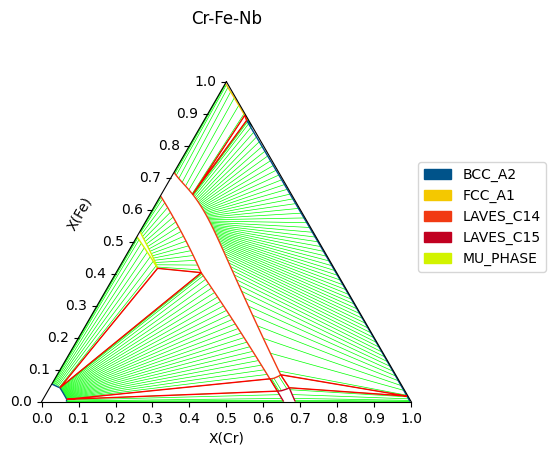

In [3]:
plt.show()